In [2]:
import numpy as np

# Parámetros
n = 100  # longitud del vector

# Generador moderno
rng = np.random.default_rng(seed=123)  # opcional

# Vector de variables aleatorias Uniforme(0,1)
X = rng.uniform(low=0.0, high=1.0, size=n)

print(X)

[0.68235186 0.05382102 0.22035987 0.18437181 0.1759059  0.81209451
 0.923345   0.2765744  0.81975456 0.88989269 0.51297046 0.2449646
 0.8242416  0.21376296 0.74146705 0.6299402  0.92740726 0.23190819
 0.79912513 0.51816504 0.23155562 0.16590399 0.49778897 0.58272464
 0.18433799 0.01489492 0.47113323 0.72824333 0.91860049 0.62553401
 0.91712257 0.86469025 0.21814287 0.86612743 0.73075194 0.27786529
 0.79704355 0.86522171 0.2994379  0.52704208 0.07148681 0.58323841
 0.2379064  0.76496365 0.17363164 0.31274226 0.01447448 0.03255192
 0.49670184 0.46831253 0.12769032 0.2575625  0.00318111 0.38106775
 0.57587308 0.42729877 0.83510235 0.61649125 0.26608391 0.81102211
 0.49948675 0.75881032 0.56608909 0.43744036 0.39615444 0.02223529
 0.46935079 0.6235584  0.94611342 0.43532608 0.4856414  0.51911514
 0.40859098 0.57879572 0.07035067 0.48838383 0.61014483 0.74387911
 0.42983032 0.30280213 0.00589003 0.75647897 0.07757597 0.48998804
 0.3043611  0.84082216 0.95047586 0.31887458 0.89776829 0.33752

In [395]:
import numpy as np

def random_walking(probabilities, starting_position, emergence_threshold, rng=None):
    """
    Parameters
    ----------
    pprobabilities : array-like
        Vector of success transition probabilities (values between 0 and 1).
    starting_position : int
        Initial position (1, ..., n).
    
    emergence_threshold : int
        Minimum path length required for emergence.
        
    rng : numpy.random.Generator, optional
        Random number generator used to generate independent Uniform(0,1)
        random variables. If omitted, a NumPy default random number
        generator is created automatically.

    Returns
    -------
    path_length : int
        Number of successful moves before the game terminates.
    outcome : str
    One of:
        - 'emerged': the required path length for emergence was reached.
        - 'failure': a transition failed.
        - 'return': the walker returned to the starting position before
          emergence. This is an artificial stopping criterion introduced
          to guarantee that the simulation always terminates.
    """

    if not (1 <= starting_position <= len(probabilities)):
        raise ValueError(
            f"'starting_position' must be between 1 and {len(probabilities)}. "
            f"Input given: {starting_position}."
        )
    
    if not (1 <= emergence_threshold <= len(probabilities)):
        raise ValueError(
            f"'emergence_threshol' must be between 1 and {len(probabilities)}. Input given: {emergence_threshold}."
        )

    if rng is None:
        rng = np.random.default_rng()

    n = len(probabilities)

    # Convert to Python's zero-based indexing
    starting_position -= 1
    position = starting_position
    path_length = 0

    while True:

        # Generate an auxiliary Uniform(0,1) random variable
        u = rng.random()

        # Successful transition
        if u <= probabilities[position]:

            path_length += 1
            position = (position + 1) % n
            
            # The required path length for emergence has been reached
            if path_length >= emergence_threshold:
                return path_length, "emerged"

            # Artificial stopping criterion to guarantee a finite simulation
            # The walker has returned to the starting position
            if position == starting_position:
                return path_length, "return"

        # Transition failed
        else:
            return path_length, "failure"

In [396]:
rng = np.random.default_rng()

# Probability vector
p = rng.random(2)

# Simulate a game starting at position 20
path_length, outcome = random_walking(probabilities=p, starting_position=2, emergence_threshold=1, rng=rng)

print(path_length)
print(outcome)

1
emerged


In [401]:
import numpy as np

def random_walking(probabilities, starting_position, emergence_threshold, rng=None):
    """
    Parameters
    ----------
    probabilities : array-like
        Vector of success transition probabilities (values between 0 and 1).
    starting_position : int
        Initial position (1, ..., n).

    emergence_threshold : int
        Minimum path length required for emergence.

    rng : numpy.random.Generator, optional
        Random number generator used to generate independent Uniform(0,1)
        random variables. If omitted, a NumPy default random number
        generator is created automatically.

    Returns
    -------
    path_length : int
        Number of successful moves before the game terminates.

    outcome : str
        One of:
        - 'emerged': the required path length for emergence was reached.
        - 'failure': a transition failed.
        - 'return': the walker returned to the starting position before
          emergence.

    path : list
        Sequence of visited positions during the random walk.
    """

    if not (1 <= starting_position <= len(probabilities)):
        raise ValueError(
            f"'starting_position' must be between 1 and {len(probabilities)}. "
            f"Input given: {starting_position}."
        )

    if not (1 <= emergence_threshold <= len(probabilities)):
        raise ValueError(
            f"'emergence_threshold' must be between 1 and {len(probabilities)}. "
            f"Input given: {emergence_threshold}."
        )

    if rng is None:
        rng = np.random.default_rng()

    n = len(probabilities)

    # Convert to Python's zero-based indexing
    starting_position -= 1
    position = starting_position

    path_length = 0
    path = [position + 1]  # Store positions as 1,...,n

    while True:

        # Generate an auxiliary Uniform(0,1) random variable
        u = rng.random()

        # Successful transition
        if u <= probabilities[position]:

            path_length += 1
            position = (position + 1) % n

            # Record new position
            path.append(position + 1)

            # Emergence criterion
            if path_length >= emergence_threshold:
                return path_length, "emerged", path

            # Artificial stopping criterion
            if position == starting_position:
                return path_length, "return", path

        # Transition failed
        else:
            return path_length, "failure", path

In [556]:
rng = np.random.default_rng()

p = rng.random(5)

path_length, outcome, path = random_walking(
    probabilities=p,
    starting_position=5,
    emergence_threshold=5,
    rng=rng
)

print("Path:", path)
print("Length:", path_length)
print("Outcome:", outcome)

Path: [5, 1, 2, 3, 4, 5]
Length: 5
Outcome: emerged


In [817]:
import numpy as np


def random_walking(probabilities, starting_position, emergence_threshold, rng=None):
    """
    Simulate a circular random walk until emergence, failure, or return.

    Parameters
    ----------
    probabilities : array-like
        Vector of success transition probabilities (values between 0 and 1).

    starting_position : int
        Initial position of the walker (1, ..., n).

    emergence_threshold : int
        Minimum path length required for emergence.

    rng : numpy.random.Generator, optional
        Random number generator used to generate independent Uniform(0,1)
        random variables. If omitted, a NumPy default random number
        generator is created automatically.

    Returns
    -------
    path_length : int
        Number of successful moves before the game terminates.

    outcome : str
        One of:
        - 'emerged': the emergence threshold was reached.
        - 'failure': a transition failed.
        - 'return': the walker returned to the starting position before
          reaching emergence. This is an artificial stopping criterion
          introduced to guarantee a finite simulation.

    final_position : int
        Final position reached by the walker (1, ..., n).

    path : list
        Sequence of visited positions during the random walk.
    """

    n = len(probabilities)

    if not (1 <= starting_position <= n):
        raise ValueError(
            f"'starting_position' must be between 1 and {n}. "
            f"Input given: {starting_position}."
        )

    if not (1 <= emergence_threshold <= n):
        raise ValueError(
            f"'emergence_threshold' must be between 1 and {n}. "
            f"Input given: {emergence_threshold}."
        )

    if rng is None:
        rng = np.random.default_rng()

    # Convert to Python zero-based indexing
    start = starting_position - 1
    position = start

    path_length = 0
    path = [starting_position]

    while True:

        # Generate Uniform(0,1) random variable
        u = rng.random()

        # Successful transition
        if u <= probabilities[position]:

            path_length += 1

            # Move to next position in a circular board
            position = (position + 1) % n

            # Store position using 1,...,n indexing
            path.append(position + 1)

            # Emergence criterion
            if path_length >= emergence_threshold:
                return (
                    path_length,
                    "emerged",
                    position + 1,
                    path
                )

            # Artificial stopping criterion
            if position == start:
                return (
                    path_length,
                    "return",
                    position + 1,
                    path
                )

        # Failed transition
        else:
            return (
            path_length,
            "failure",
            position + 1,
            path
        )


In [835]:
rng = np.random.default_rng()

probabilities = [0.89,0.7,0.48,0.3,1]

starting_position = 5
emergence_threshold = 2

results = []

for _ in range(500):

    path_length, outcome, final_position, path = random_walking(
        probabilities=probabilities,
        starting_position=starting_position,
        emergence_threshold=emergence_threshold,
        rng=rng
    )

    results.append(
        {
            "path_length": path_length,
            "outcome": outcome,
            "final_position": final_position
        }
    )
    
emergence_probability = (
    sum(r["outcome"] == "emerged" for r in results)
    / len(results)
)

print(emergence_probability)

0.89


In [1]:
emergence_positions = [
    r["final_position"]
    for r in results
    if r["outcome"] == "emerged"
]

ci = np.quantile(
    emergence_positions,
    [0.025, 0.975]
)

emergence_lengths = [
    r["path_length"]
    for r in results
    if r["outcome"] == "emerged"
]

ci_2 = np.quantile(
    emergence_lengths,
    [0.025, 0.975]
)

NameError: name 'results' is not defined

In [840]:
print(ci_2)

[2. 2.]


In [841]:
print(emergence_positions)

[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 

In [926]:
import numpy as np


def random_walking(probabilities, starting_position, emergence_threshold, rng=None):
    """
    Simulate a circular random walk with an emergence threshold.

    Parameters
    ----------
    probabilities : array-like
        Vector of transition success probabilities (values between 0 and 1).

    starting_position : int
        Initial position of the walker (1, ..., n).

    emergence_threshold : int
        Path length at which emergence is recorded.

    rng : numpy.random.Generator, optional
        Random number generator used to generate independent Uniform(0,1)
        random variables. If omitted, a NumPy default random number
        generator is created automatically.

    Returns
    -------
    path_length : int
        Total number of successful moves before termination.

    outcome : str
        Termination condition: 'failure' or 'return'.

    emerged : bool
        True if the emergence threshold was reached.

    emergence_position : int or None
        Position where emergence occurred.

    emergence_time : int or None
        Path length when emergence occurred.

    path : list
        Sequence of visited positions.
    """

    n = len(probabilities)

    if not (1 <= starting_position <= n):
        raise ValueError(
            f"'starting_position' must be between 1 and {n}."
        )

    if not (1 <= emergence_threshold <= n):
        raise ValueError(
            f"'emergence_threshold' must be between 1 and {n}."
        )

    if rng is None:
        rng = np.random.default_rng()

    start = starting_position - 1
    position = start

    path_length = 0
    path = [starting_position]

    emerged = False
    emergence_position = None
    emergence_time = None

    while True:

        u = rng.random()

        # Successful transition
        if u <= probabilities[position]:

            path_length += 1
            position = (position + 1) % n

            path.append(position + 1)

            # Record emergence only once
            if (not emerged) and (path_length >= emergence_threshold):
                emerged = True
                emergence_position = position + 1
                emergence_time = path_length

            # Stop if returned to initial position
            if position == start:

                if emerged:
                    return (
                        emerged,
                        path_length,
                        "emerged_return",
                        emergence_position,
                        emergence_time,
                        path
                    )
                else:
                    return (
                        emerged,
                        path_length,
                        "return",
                        emergence_position,
                        emergence_time,
                        path
                    )

        # Failed transition
        else:

            if emerged:
                return (
                    emerged,
                    path_length,
                    "emerged_failure",
                    emergence_position,
                    emergence_time,
                    path
                )
            else:
                return (
                    emerged,
                    path_length,
                    "failure",
                    None,
                    None,
                    path
                )

In [931]:
rng = np.random.default_rng()

# Tablero de 10 posiciones donde siempre se avanza
probabilities =  [0.89,0.7,0.48,0.3,1,0.89,0.7,0.48,0.3,1]

result = random_walking(
    probabilities=probabilities,
    starting_position=5,
    emergence_threshold=4,
    rng=rng
)

print(result)

(True, 4, 'emerged_failure', 9, 4, [5, 6, 7, 8, 9])


In [932]:
pip install networkx

Note: you may need to restart the kernel to use updated packages.


In [933]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt


def plot_transition_graph(probabilities):

    n = len(probabilities)

    G = nx.DiGraph()

    # Add states
    states = [f"D{i+1}" for i in range(n)]
    states.append("F")

    G.add_nodes_from(states)

    # Add transitions
    for i, p in enumerate(probabilities):

        current = f"D{i+1}"

        # Circular transition
        next_state = f"D{(i+1)%n + 1}"

        G.add_edge(
            current,
            next_state,
            weight=p
        )

        # Failure transition
        G.add_edge(
            current,
            "F",
            weight=1-p
        )

    # Layout
    pos = nx.circular_layout(G)

    plt.figure(figsize=(10,10))

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=800
    )

    nx.draw_networkx_labels(
        G,
        pos
    )

    # Edges
    nx.draw_networkx_edges(
        G,
        pos,
        arrows=True,
        arrowsize=20
    )

    # Edge labels
    labels = {
        (u,v): f"{d['weight']:.2f}"
        for u,v,d in G.edges(data=True)
    }

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=labels
    )

    plt.axis("off")
    plt.show()

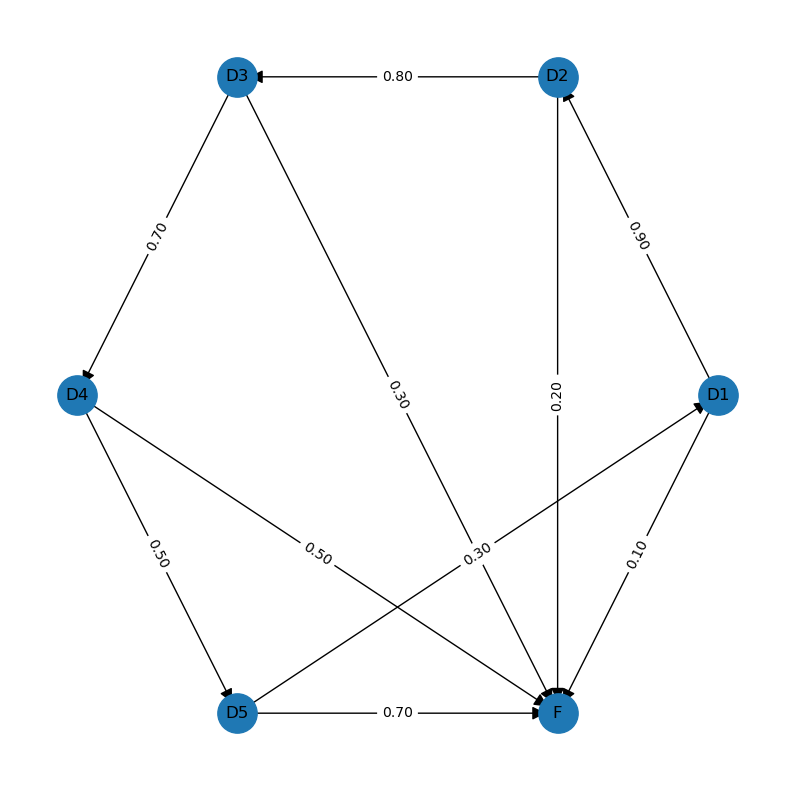

In [934]:
p = np.array([0.9, 0.8, 0.7, 0.5, 0.3])

plot_transition_graph(p)

In [941]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt


def plot_transition_graph(probabilities):

    n = len(probabilities)

    G = nx.DiGraph()

    # Add nodes
    states = [f"D{i+1}" for i in range(n)]
    G.add_nodes_from(states)
    G.add_node("F")

    # Add weighted edges
    for i, p in enumerate(probabilities):

        current = f"D{i+1}"

        # Cyclic transition
        next_state = f"D{(i+1)%n + 1}"

        G.add_edge(
            current,
            next_state,
            weight=p,
            transition="success"
        )

        # Failure transition
        G.add_edge(
            current,
            "F",
            weight=1-p,
            transition="failure"
        )

    # -------------------------
    # Custom layout
    # -------------------------

    pos = {}

    # Failure node at center
    pos["F"] = np.array([0, 0])

    # Circular arrangement of states
    radius = 3

    for i, state in enumerate(states):

        angle = 2*np.pi*i/n

        pos[state] = np.array([
            radius*np.cos(angle),
            radius*np.sin(angle)
        ])

    # -------------------------
    # Plot
    # -------------------------

    plt.figure(figsize=(10, 10))

    # Nodes
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=states,
        node_size=700
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=["F"],
        node_size=1000
    )

    # Labels
    nx.draw_networkx_labels(
        G,
        pos
    )

    # Edges
    nx.draw_networkx_edges(
        G,
        pos,
        arrows=True,
        arrowsize=20,
        connectionstyle="arc3,rad=0.1"
    )

    # Edge weights
    edge_labels = {
        (u, v): f"{d['weight']:.2f}"
        for u, v, d in G.edges(data=True)
    }
    
    # -------------------------
    # Draw weighted edges
    # -------------------------

    edge_widths = []
    edge_colors = []

    for u, v, d in G.edges(data=True):

        # Scale edge width according to transition probability
        edge_widths.append(5 * d["weight"])

        # Distinguish failure transitions
        if v == "F":
            edge_colors.append("black")
        else:
            edge_colors.append("black")


    nx.draw_networkx_edges(
        G,
        pos,
        arrows=True,
        arrowsize=20,
        width=edge_widths,
        edge_color=edge_colors,
        connectionstyle="arc3,rad=0.1"
    )


    plt.axis("equal")
    plt.axis("off")
    plt.show()

C:\Users\amigo\AppData\Local\Temp\ipykernel_11016\1822957635.py:122: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(


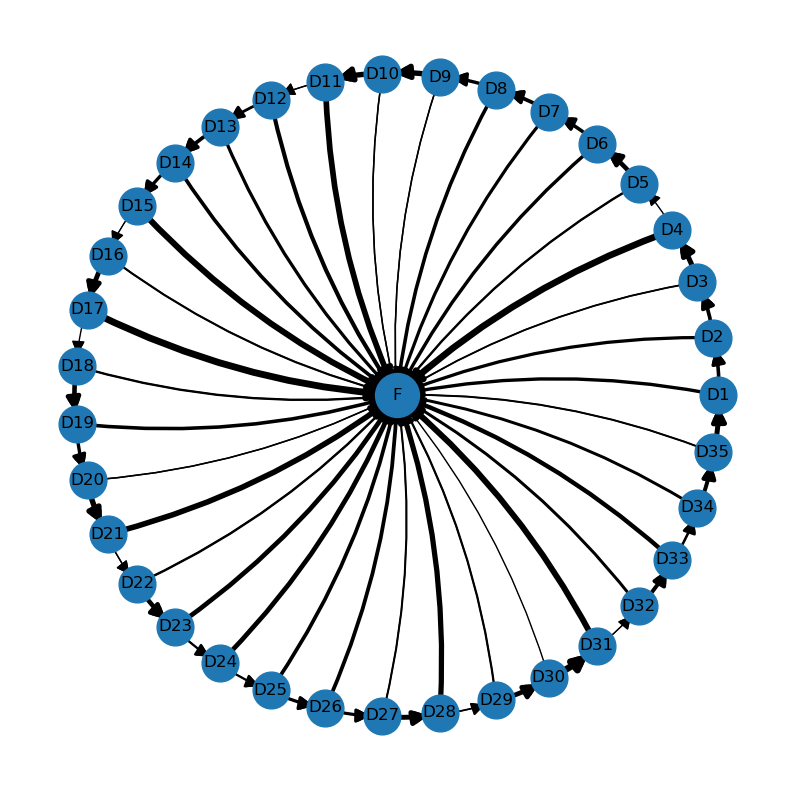

In [944]:
#p = np.array([0.9, 0.8, 0.7, 0.6, 0.5])

p = rng.random(35)
plot_transition_graph(p)